# 05 — Differential Abundance

Test all 128 genera for differences between RA and HC.

Mann-Whitney U per genus, Benjamini-Hochberg FDR correction across all tests,
Cliff's delta for effect size.

At n=1,928, significance is cheap. Interpretation keys on effect size, not q-value.

Primary cohort: Beijing (n=1,928). Replication check on non-Beijing (n=310).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, os.path.abspath('..'))
from config import PARAMS, PATHS

PROCESSED = "../data/processed/"
FIGURES   = "../results/figures/"
TABLES    = "../results/tables/"

counts = pd.read_csv(PROCESSED + "genus_counts.csv", index_col="sample_id")
clr_df = pd.read_csv(PROCESSED + "genus_clr.csv",    index_col="sample_id")
meta   = pd.read_csv(PROCESSED + "metadata.csv",     index_col="sample_id")

beijing_samples = meta.index[meta["location"] == "Beijing"]
other_samples   = meta.index[meta["location"] != "Beijing"]

meta_bj = meta.loc[beijing_samples]
clr_bj  = clr_df.loc[beijing_samples]

meta_other = meta.loc[other_samples]
clr_other  = clr_df.loc[other_samples]

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print(f"Beijing: {clr_bj.shape[0]} samples, {clr_bj.shape[1]} genera")
print(f"Non-Beijing: {clr_other.shape[0]} samples")

Beijing: 1928 samples, 128 genera
Non-Beijing: 310 samples


## Effect size functions

Cliff's delta: P(x > y) - P(x < y). Range -1 to 1, non-parametric.
Positive = higher in RA.

Thresholds (Romano et al.): <0.147 negligible, <0.33 small,
<0.474 medium, else large.

In [2]:
def cliffs_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    n_greater = sum((xi > y).sum() for xi in x)
    n_less    = sum((xi < y).sum() for xi in x)
    return (n_greater - n_less) / (len(x) * len(y))


def interpret_delta(d):
    ad = abs(d)
    if ad < 0.147: return "negligible"
    if ad < 0.330: return "small"
    if ad < 0.474: return "medium"
    return "large"

## Test all genera

One Mann-Whitney U test per genus, then FDR-correct across all 128.

Without correction, 128 tests at p<0.05 would yield ~6 false positives by chance.
Benjamini-Hochberg controls the expected proportion of false positives among
significant results rather than the chance of any false positive, which is less
conservative than Bonferroni and appropriate for correlated features.

In [3]:
def run_differential_abundance(clr_data, meta_data):
    """Test every genus for RA vs HC difference. Returns FDR-corrected results."""
    results = []

    for genus in clr_data.columns:
        hc = clr_data.loc[meta_data.disease_status == "HC", genus]
        ra = clr_data.loc[meta_data.disease_status == "RA", genus]

        stat, p = mannwhitneyu(ra, hc)
        d = cliffs_delta(ra, hc)

        results.append({
            "genus":    genus,
            "HC_mean":  hc.mean(),
            "RA_mean":  ra.mean(),
            "diff":     ra.mean() - hc.mean(),
            "p_value":  p,
            "cliffs_d": d,
        })

    df = pd.DataFrame(results)
    _, qvals, _, _ = multipletests(df["p_value"], method="fdr_bh")
    df["q_value"] = qvals
    df["effect"]  = df["cliffs_d"].apply(interpret_delta)

    return df.sort_values("cliffs_d", ascending=False).reset_index(drop=True)


da = run_differential_abundance(clr_bj, meta_bj)

print(f"Genera tested:                   {len(da)}")
print(f"Significant (q < 0.05):          {(da.q_value < 0.05).sum()}")
print(f"  with non-negligible effect:    {((da.q_value < 0.05) & (da.effect != 'negligible')).sum()}")
print(f"  with small+ effect:            {((da.q_value < 0.05) & (da.cliffs_d.abs() >= 0.147)).sum()}")
print(f"  with medium+ effect:           {((da.q_value < 0.05) & (da.cliffs_d.abs() >= 0.330)).sum()}")

Genera tested:                   128
Significant (q < 0.05):          96
  with non-negligible effect:    46
  with small+ effect:            46
  with medium+ effect:           0


## Results — enriched and depleted in RA

Sorted by effect size, not significance.

In [4]:
sig = da[da.q_value < 0.05].copy()

print("TOP 15 ENRICHED IN RA (by effect size)")
print(sig.nlargest(15, "cliffs_d")[
    ["genus", "HC_mean", "RA_mean", "diff", "cliffs_d", "effect", "q_value"]
].round(4).to_string(index=False))

print("\n\nTOP 15 DEPLETED IN RA (by effect size)")
print(sig.nsmallest(15, "cliffs_d")[
    ["genus", "HC_mean", "RA_mean", "diff", "cliffs_d", "effect", "q_value"]
].round(4).to_string(index=False))

da.to_csv(TABLES + "differential_abundance_beijing.csv", index=False)

TOP 15 ENRICHED IN RA (by effect size)
                       genus  HC_mean  RA_mean   diff  cliffs_d effect  q_value
                 Veillonella  -0.8696  -0.0350 0.8346    0.2741  small      0.0
            Terrisporobacter  -1.3590  -0.8714 0.4877    0.2683  small      0.0
      Erysipelatoclostridium  -0.9902  -0.1302 0.8600    0.2566  small      0.0
 [Ruminococcus] gnavus group   0.8299   2.1375 1.3076    0.2510  small      0.0
                      Rothia  -1.6155  -1.3418 0.2738    0.2460  small      0.0
Lachnospiraceae NC2004 group  -1.3779  -1.0396 0.3383    0.2431  small      0.0
   Defluviitaleaceae UCG-011  -1.6612  -1.4988 0.1625    0.2367  small      0.0
                 Haemophilus  -1.6272  -1.4447 0.1825    0.2346  small      0.0
                Tyzzerella 4  -1.0682  -0.2543 0.8139    0.2344  small      0.0
               GCA-900066225  -1.6193  -1.4481 0.1712    0.2334  small      0.0
                  Sellimonas  -1.4646  -1.1911 0.2735    0.2280  small      0.0
 

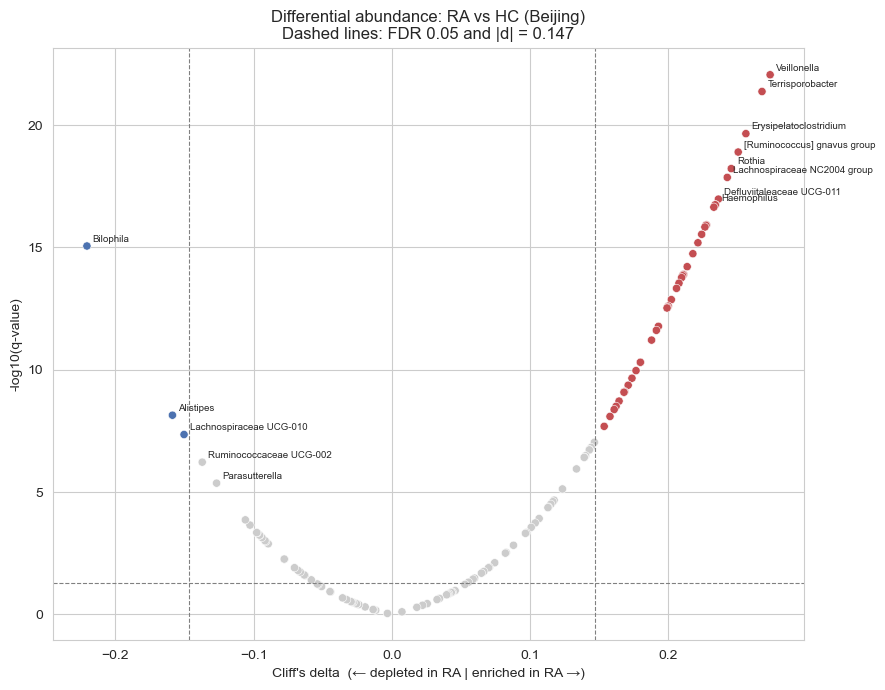

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

da["neglog_q"] = -np.log10(da["q_value"].clip(lower=1e-300))

colours = []
for _, r in da.iterrows():
    if r.q_value >= 0.05 or abs(r.cliffs_d) < 0.147:
        colours.append("#cccccc")
    elif r.cliffs_d > 0:
        colours.append("#C44E52")
    else:
        colours.append("#4C72B0")

ax.scatter(da["cliffs_d"], da["neglog_q"], c=colours, s=35,
           edgecolor="white", linewidth=0.4)

ax.axvline(0.147,  ls="--", c="grey", lw=0.8)
ax.axvline(-0.147, ls="--", c="grey", lw=0.8)
ax.axhline(-np.log10(0.05), ls="--", c="grey", lw=0.8)

# Label the genera with the largest effects
for _, r in pd.concat([da.nlargest(8, "cliffs_d"), da.nsmallest(5, "cliffs_d")]).iterrows():
    ax.annotate(r.genus, (r.cliffs_d, r.neglog_q), fontsize=7,
                xytext=(4, 3), textcoords="offset points")

ax.set_xlabel("Cliff's delta  (← depleted in RA | enriched in RA →)")
ax.set_ylabel("-log10(q-value)")
ax.set_title("Differential abundance: RA vs HC (Beijing)\nDashed lines: FDR 0.05 and |d| = 0.147")
plt.tight_layout()
plt.savefig(FIGURES + "volcano.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
# Run the same tests on the 310 non-Beijing samples
da_other = run_differential_abundance(clr_other, meta_other)

# Merge the two result sets
comp = da[["genus", "cliffs_d", "q_value", "effect"]].merge(
    da_other[["genus", "cliffs_d", "q_value", "effect"]],
    on="genus", suffixes=("_bj", "_other")
)

# Same direction of effect in both cohorts?
comp["same_direction"] = np.sign(comp.cliffs_d_bj) == np.sign(comp.cliffs_d_other)

# Replicated = significant in Beijing with real effect, and same direction + significant elsewhere
comp["replicated"] = (
    (comp.q_value_bj < 0.05) & (comp.cliffs_d_bj.abs() >= 0.147) &
    (comp.q_value_other < 0.05) & comp.same_direction
)

bj_hits = comp[(comp.q_value_bj < 0.05) & (comp.cliffs_d_bj.abs() >= 0.147)]

print(f"Beijing hits (q<0.05, |d|>=0.147): {len(bj_hits)}")
print(f"  same direction in non-Beijing:    {bj_hits.same_direction.sum()}")
print(f"  also significant in non-Beijing:  {bj_hits.replicated.sum()}")

print("\nTop Beijing hits with replication status:")
print(bj_hits.nlargest(15, "cliffs_d_bj")[
    ["genus", "cliffs_d_bj", "cliffs_d_other", "q_value_other", "same_direction", "replicated"]
].round(4).to_string(index=False))

comp.to_csv(TABLES + "replication_comparison.csv", index=False) 

print("\nDirection flip:")
print(bj_hits[~bj_hits.same_direction][
    ["genus", "cliffs_d_bj", "cliffs_d_other", "q_value_other"]
].round(4).to_string(index=False))

Beijing hits (q<0.05, |d|>=0.147): 46
  same direction in non-Beijing:    45
  also significant in non-Beijing:  38

Top Beijing hits with replication status:
                       genus  cliffs_d_bj  cliffs_d_other  q_value_other  same_direction  replicated
                 Veillonella       0.2741          0.3359         0.0001            True        True
            Terrisporobacter       0.2683          0.3153         0.0002            True        True
      Erysipelatoclostridium       0.2566          0.3698         0.0000            True        True
 [Ruminococcus] gnavus group       0.2510          0.2727         0.0008            True        True
                      Rothia       0.2460          0.3115         0.0002            True        True
Lachnospiraceae NC2004 group       0.2431          0.0273         0.7750            True       False
   Defluviitaleaceae UCG-011       0.2367          0.3241         0.0001            True        True
                 Haemophilus     

In [ ]:
 =